Debug notebook to output bottom-layer metabolic index data for all species and three selected nodes

In [1]:
output_dir = '../run/SSM_output'

specified_nodes = [13789, 8841, 14409]

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd

In [2]:
output_dirs = list((Path(output_dir) / 'SSM_metabolic').glob('CalMinParam_3D_*_Mindex_routine'))
output_dirs

[PosixPath('../run/SSM_output/SSM_metabolic/CalMinParam_3D_salmon_Mindex_routine'),
 PosixPath('../run/SSM_output/SSM_metabolic/CalMinParam_3D_crab_Mindex_routine'),
 PosixPath('../run/SSM_output/SSM_metabolic/CalMinParam_3D_sole_Mindex_routine')]

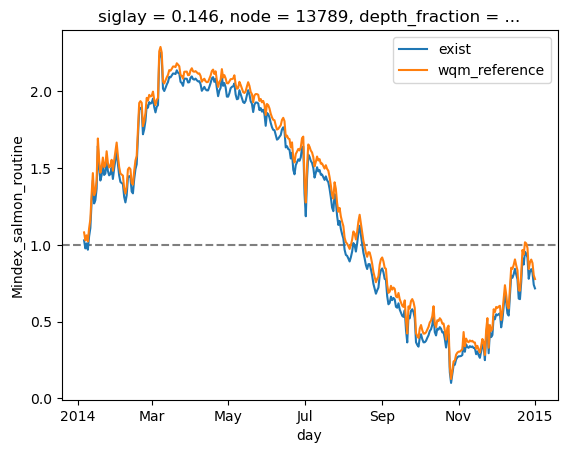

In [3]:
for d in output_dirs:
    fig, ax = plt.subplots()
    ax.axhline(1, linestyle='--', color='tab:gray')
    for scn in ('exist','wqm_reference'):
        with xr.open_dataset(d / f'{scn}.nc') as mi_data:
            var = next(iter(mi_data.variables.keys()))
            mi_data[var][:,-1,specified_nodes[0]-1].plot(ax=ax, label=scn)
            times = mi_data['day'][:]
    break
ax.legend()

In [4]:
dfs = {}
for d in output_dirs:
    data = {}
    for node in specified_nodes:
        data[node] = {}
    for scn in ('exist','wqm_reference'):
        with xr.open_dataset(d / f'{scn}.nc') as mi_data:
            var = next(iter(mi_data.variables.keys()))
            for node in specified_nodes:
                data[node][scn] = mi_data[var][:,-1,node-1].to_pandas()
    dfs[d.name] = {}
    for node in specified_nodes:
        df = pd.DataFrame(data[node])
        df.to_excel(Path(output_dir) / 'SSMspreadsheets' / f'{d.name}_node{node}.xlsx')
        dfs[d.name][node] = df

Next, use this data to compute area statistics as a way to test that particular function

In [5]:
sys.path.append('../py_scripts')
import ssm_utils
from helper_create_statistics_dataframes import create_statistics_dataframes

In [6]:
ssm, case = ssm_utils.read_case('../run/SSM_config_mi.yaml')

Inferring case name to be mi


In [7]:
gdf = gpd.read_file(ssm['paths']['shapefile']).set_index('tce')
for calc,dfs_by_node in dfs.items():
    daily_areas = {scn: {} for scn in dfs_by_node[next(iter(dfs_by_node.keys()))]}
    regions = []
    for node,df in dfs_by_node.items():
        node_area = gdf.loc[node, 'Area_m2'] * 1e-6
        region = gdf.loc[node, 'region_inf']
        regions.append(region)
        for scn in df.columns:
            daily_areas[scn][region] = (df[scn].to_numpy() < 1) * node_area
    results = create_statistics_dataframes(case, ssm, 'area', daily_areas,
                                           regions, pd.DatetimeIndex(times))
    print(calc)
    print('Existing')
    display(results['exist'])
    print('Reference')
    display(results['wqm_reference'])

CalMinParam_3D_salmon_Mindex_routine
Existing


,Region,Total_Area_km2,Avg_Area_km2,AvgArea_%ofTotal,AvgArea_Compr_km2,AvgArea_Compr_%ofTotal,Compr_Start_M/D,Compr_End_M/D,Min_Area_km2,Min_Date_M/D,MinArea_%ofTotal,Max_Area_km2,Max_Date_M/D,MaxArea_%ofTotal
0,Hood,289.618,0.148184,0.051,0.148016,0.051,01/07,01/01,0.0,01/06,NaN,0.356630,01/07,0.123
1,Whidbey,390.528,0.063474,0.016,0.524592,0.134,09/01,10/13,0.0,01/06,NaN,0.881314,09/01,0.226
2,South_Sound,326.884,0.000000,NaN,NaN,NaN,N/A,N/A,0.0,01/06,NaN,0.000000,01/06,NaN


Reference


,Region,Total_Area_km2,Avg_Area_km2,AvgArea_%ofTotal,AvgArea_Compr_km2,AvgArea_Compr_%ofTotal,Compr_Start_M/D,Compr_End_M/D,Min_Area_km2,Min_Date_M/D,MinArea_%ofTotal,Max_Area_km2,Max_Date_M/D,MaxArea_%ofTotal
0,Hood,289.618,0.136329,0.047,0.327908,0.113,08/05,01/01,0.0,01/06,NaN,0.356630,08/05,0.123
1,Whidbey,390.528,0.024413,0.006,0.317273,0.081,09/18,10/13,0.0,01/06,NaN,0.881314,09/18,0.226
2,South_Sound,326.884,0.000000,NaN,NaN,NaN,N/A,N/A,0.0,01/06,NaN,0.000000,01/06,NaN


CalMinParam_3D_crab_Mindex_routine
Existing


...

,Region,Total_Area_km2,Avg_Area_km2,AvgArea_%ofTotal,AvgArea_Compr_km2,AvgArea_Compr_%ofTotal,Compr_Start_M/D,Compr_End_M/D,Min_Area_km2,Min_Date_M/D,MinArea_%ofTotal,Max_Area_km2,Max_Date_M/D,MaxArea_%ofTotal
0,Hood,289.618,0.106693,0.037,0.298120,0.103,08/26,01/01,0.0,01/06,NaN,0.356630,08/26,0.123
1,Whidbey,390.528,0.004883,0.001,0.881314,0.226,09/21,09/22,0.0,01/06,NaN,0.881314,09/21,0.226
2,South_Sound,326.884,0.000000,NaN,NaN,NaN,N/A,N/A,0.0,01/06,NaN,0.000000,01/06,NaN


CalMinParam_3D_sole_Mindex_routine
Existing


,Region,Total_Area_km2,Avg_Area_km2,AvgArea_%ofTotal,AvgArea_Compr_km2,AvgArea_Compr_%ofTotal,Compr_Start_M/D,Compr_End_M/D,Min_Area_km2,Min_Date_M/D,MinArea_%ofTotal,Max_Area_km2,Max_Date_M/D,MaxArea_%ofTotal
0,Hood,289.618,0.103729,0.036,0.289762,0.100,08/26,01/01,0.0,01/06,NaN,0.356630,08/26,0.123
1,Whidbey,390.528,0.004883,0.001,0.881314,0.226,09/21,09/22,0.0,01/06,NaN,0.881314,09/21,0.226
2,South_Sound,326.884,0.000000,NaN,NaN,NaN,N/A,N/A,0.0,01/06,NaN,0.000000,01/06,NaN


Reference


,Region,Total_Area_km2,Avg_Area_km2,AvgArea_%ofTotal,AvgArea_Compr_km2,AvgArea_Compr_%ofTotal,Compr_Start_M/D,Compr_End_M/D,Min_Area_km2,Min_Date_M/D,MinArea_%ofTotal,Max_Area_km2,Max_Date_M/D,MaxArea_%ofTotal
0,Hood,289.618,0.095826,0.033,0.326061,0.113,09/06,12/20,0.0,01/06,NaN,0.35663,09/06,0.123
1,Whidbey,390.528,0.000000,NaN,NaN,NaN,N/A,N/A,0.0,01/06,NaN,0.00000,01/06,NaN
2,South_Sound,326.884,0.000000,NaN,NaN,NaN,N/A,N/A,0.0,01/06,NaN,0.00000,01/06,NaN
